In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'C:\Projects\Mule-tiplier\data\raw\HI-Small_Trans.csv')

In [11]:
df

,Timestamp,From Bank,from_Account,To Bank,to_Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022-09-10 23:57:00,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0
5078341,2022-09-10 23:35:00,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0
5078342,2022-09-10 23:52:00,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0
5078343,2022-09-10 23:46:00,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0


In [4]:
df.rename(columns={'Account':'from_Account', 'Account.1':'to_Account'}, inplace=True)
df

,Timestamp,From Bank,from_Account,To Bank,to_Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0


In [5]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Timestamp           datetime64[us]
 1   From Bank           int64         
 2   from_Account        str           
 3   To Bank             int64         
 4   to_Account          str           
 5   Amount Received     float64       
 6   Receiving Currency  str           
 7   Amount Paid         float64       
 8   Payment Currency    str           
 9   Payment Format      str           
 10  Is Laundering       int64         
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 426.2 MB


In [6]:
def build_graph(df: pd.DataFrame) -> nx.DiGraph:
    G = nx.DiGraph()
    for i, row in df.iterrows():
        G.add_edge(
            row['from_Account'], row['to_Account'],
            amount = row['Amount Paid'],
            timestamp = row['Timestamp'],
            is_laundering = row['Is Laundering']
        )
    return G

In [34]:
def plot_account_subgraphs(G, accounts, radius=1, output_path='../outputs/figures/subgraph_group.png'):
    # Accept a single node or an iterable of nodes
    if isinstance(accounts, (str, int)):
        seed_accounts = {accounts}
    else:
        seed_accounts = set(accounts)

    # Collect union of nodes within the radius of all target accounts
    subgraph_nodes = set()
    for acc in seed_accounts:
        if acc in G:
            subgraph_nodes.update(nx.ego_graph(G, acc, radius=radius).nodes())
        else:
            print(f"Warning: Account '{acc}' not found in graph.")

    if not subgraph_nodes:
        print("No valid accounts to plot.")
        return

    # Extract the induced subgraph
    subG = G.subgraph(subgraph_nodes)

    pos = nx.spring_layout(subG, seed=42)

    # Highlight seed accounts in red, neighbors in lightblue
    node_colors = ['red' if n in seed_accounts else 'yellow' for n in subG.nodes()]

    plt.figure(figsize=(10, 8))
    nx.draw(
        subG,
        pos,
        with_labels=True,
        node_color=node_colors,
        node_size=100,
        font_size=8,
        arrows=True,
        arrowsize=12
    )

    plt.title(f"Subgraph for {len(seed_accounts)} Target Account(s) (Radius={radius})")
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

In [8]:
G = build_graph(df)

In [ ]:
legit_accounts = df[df['Is Laundering'] == 0]['from_Account'].unique()
plot_account_subgraphs(G, legit_accounts[:10], radius=1)

KeyboardInterrupt: 

In [36]:
laundering_accounts = df[df['Is Laundering'] == 1]['from_Account'].unique()
laundering_accounts =sorted(laundering_accounts, key=lambda x : (G.out_degree(x), G.in_degree(x)))
# for i in laundering_accounts:
#     print(G.out_degree(i), G.in_degree(i))
samp_account = laundering_accounts[len(laundering_accounts)-20]
print(G.out_degree(samp_account), G.in_degree(samp_account))

21 3


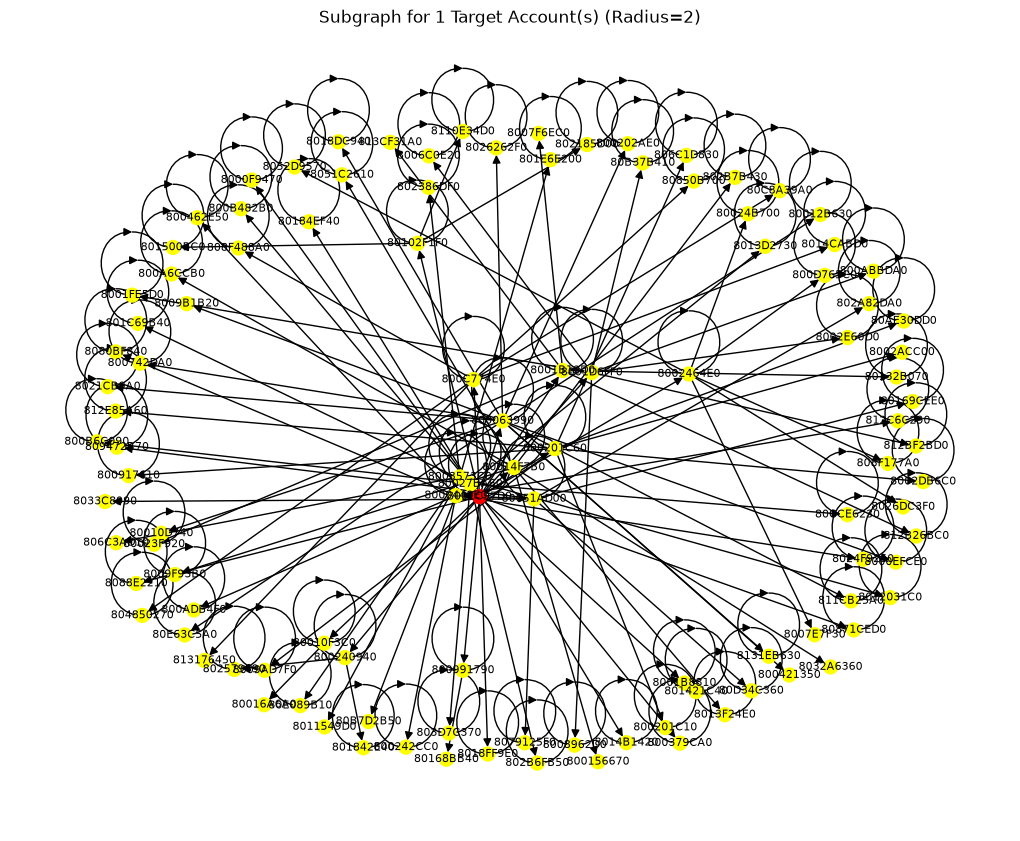

In [39]:
plot_account_subgraphs(G, [samp_account], radius=2)